In [ ]:
import duckdb

# PARQUET FILES ARE FROM https://huggingface.co/datasets/SII-WANGZJ/Polymarket_data BIG THANK YOU FOR ALL THE DATA

tradesPQ = 'X:/PolymarketData/trades.parquet'
marketPQ = 'X:/PolymarketData/markets.parquet'
usersPQ = 'X:/PolymarketData/users.parquet'

marketlist = duckdb.query(f"SELECT condition_id FROM '{marketPQ}' WHERE VOLUME > 1000000 ORDER BY RANDOM() LIMIT 10")
conditionlist = marketlist.fetchall()
print(len(conditionlist))

10


In [ ]:
conditionId = conditionlist[0][0]
# get initial db for further concats
market_df = duckdb.query(f"SELECT * FROM '{marketPQ}' WHERE condition_id = '{conditionId}'").to_df()
 # FOR SOME reason it outputs the list as a string so if "1" is at index 2 its index 0 as a list and 7 if in index 1]
winner = market_df['token1'].values[0] if market_df['outcome_prices'].values[0].index("1")== 2 else market_df['token2'].values[0]
df = duckdb.query(f"SELECT * FROM '{tradesPQ}' WHERE price < 0.95 AND price > 0.05 AND condition_id = '{conditionId}' ORDER BY RANDOM()").to_df()
df["won"] = (df["asset_id"] == winner).astype(int)


                                                    count
asset_id                                                 
30829525189835573026189534793423536095734142138...   2095
35371594261482499862869567665801433403796167035...   2347


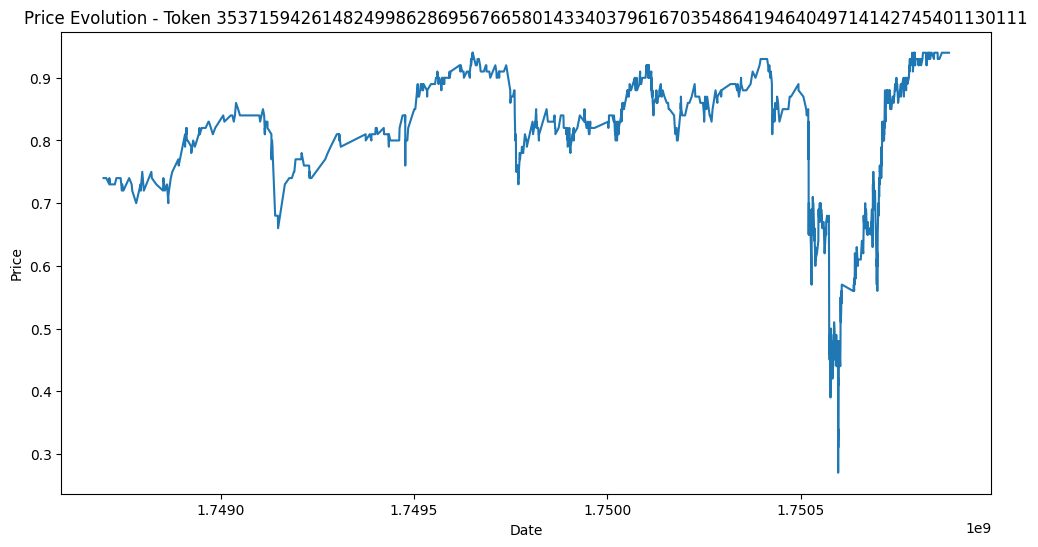

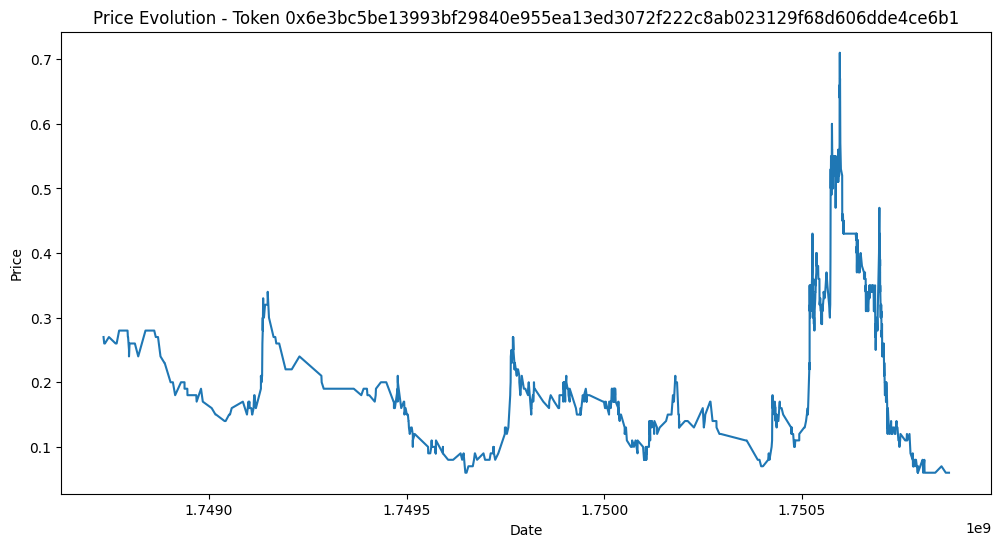

In [ ]:
from matplotlib import pyplot as plt
print(df.groupby("asset_id").agg(count = ("asset_id","count")))
df = df.sort_values("timestamp")
winnerDf = df[df["asset_id"] == winner]

# Plot price over time
plt.figure(figsize=(12, 6))
plt.plot(winnerDf['timestamp'], winnerDf['price'])
plt.title(f'Price Evolution - Token {winner}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

loserDf = df[df["asset_id"] != winner]
plt.figure(figsize=(12, 6))
plt.plot(loserDf['timestamp'], loserDf['price'])
plt.title(f'Price Evolution - Token {conditionlist[0][0]}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [ ]:
import pandas as pd


for markets in conditionlist[1:]:
    add_market_df = duckdb.query(f"SELECT * FROM '{marketPQ}' WHERE condition_id = '{markets[0]}'").to_df()
    if "'1'" not in add_market_df['outcome_prices'].values[0]:
        continue
    winner = add_market_df['token1'].values[0] if add_market_df['outcome_prices'].values[0].index("1")== 2 else add_market_df['token2'].values[0]

    add_df = duckdb.query(f"SELECT * FROM '{tradesPQ}' WHERE price > 0.4 AND price < 0.6 AND condition_id = '{markets[0]}' ORDER BY RANDOM() LIMIT 1000").to_df()
    if add_df.empty:
        continue
    add_df["won"] = (add_df["asset_id"] == winner).astype(int) 
    df = pd.concat([df,add_df],axis=0)
    market_df = pd.concat([market_df,add_market_df],axis = 0)
    print(df.shape)
print(market_df.shape)

(1057, 18)
(2057, 18)
(3057, 18)
(4057, 18)
(5057, 18)
(5067, 18)
(5069, 18)
(6069, 18)
(7069, 18)
(8069, 18)
(9069, 18)
(10069, 18)
(10197, 18)
(11197, 18)
(11241, 18)
(12241, 18)
(13241, 18)
(14241, 18)
(15241, 18)
(16241, 18)
(17241, 18)
(18241, 18)
(19241, 18)
(20241, 18)
(21241, 18)
(22241, 18)
(23241, 18)
(23936, 18)
(24936, 18)
(25936, 18)
(26936, 18)
(27936, 18)
(28936, 18)
(29936, 18)
(30936, 18)
(31936, 18)
(32452, 18)
(33361, 18)
(33701, 18)
(34701, 18)
(35447, 18)
(36447, 18)
(37447, 18)
(38447, 18)
(39447, 18)
(39749, 18)
(39845, 18)
(40845, 18)
(40868, 18)
(41868, 18)
(42868, 18)
(43405, 18)
(44293, 18)
(45293, 18)
(46293, 18)
(47190, 18)
(47489, 18)
(48424, 18)
(49424, 18)
(49642, 18)
(50642, 18)
(51353, 18)
(52353, 18)
(52653, 18)
(53653, 18)
(53796, 18)
(54796, 18)
(55625, 18)
(56625, 18)
(56644, 18)
(57430, 18)
(57671, 18)
(58671, 18)
(59671, 18)
(60671, 18)
(61671, 18)
(62671, 18)
(62710, 18)
(63710, 18)
(64710, 18)
(65108, 18)
(66108, 18)
(67108, 18)
(67548, 18)
(68

In [ ]:
df = df.merge(market_df, on='condition_id', how='left')

In [ ]:
df['end_date'] = pd.to_datetime(df['end_date'], format='ISO8601') ## endDate -> datetime
df['end_date'] = df['end_date'].apply(lambda x: x.timestamp() if pd.notna(x) else None )  ## datetime -> timestamp
df = df.dropna(subset=['end_date']) #drop if endDate is Na (about 1% of them)

df['created_at'] = pd.to_datetime(df['created_at'], format='ISO8601') ## endDate -> datetime
df['created_at'] = df['created_at'].apply(lambda x: x.timestamp() if pd.notna(x) else None )  ## datetime -> timestamp
df = df.dropna(subset=['created_at']) 


In [ ]:
df['start_to_trade'] = (df['timestamp'] - df['created_at'])
df['trade_to_end'] = (df['end_date'] - df['timestamp'])
df['relativeSizeUSD'] = (df['usd_amount']/df['volume'])
df['relativeSizeToken'] = (df['token_amount']/df['volume'])
df['confidenceShowUSD'] = (df['usd_amount']/(1-df['price']))
df['confidenceShowToken'] = (df['token_amount']/(1-df['price']))
df['hour_of_day'] = pd.to_datetime(df['timestamp'], unit='s').dt.hour
df = df.sort_values(['condition_id', 'timestamp'])
df['market_avg_size_so_far'] = df.groupby('condition_id')['usd_amount'].transform(
    lambda x: x.expanding().mean().shift(1)  # shift(1) excludes current trade
)

def count_trades_in_window(df, t=3600):
    df = df.sort_values('timestamp').copy()
    df['window_trade_count'] = 0
    
    for id, group in df.groupby('condition_id'):
        timestamps = group['timestamp'].values
        counts = [(timestamps >= ts - t).sum() 
                  for ts in timestamps]
        df.loc[group.index, 'window_trade_count'] = counts
    
    return df

df = count_trades_in_window(df)

In [ ]:
print(df.describe())

          timestamp  block_number      log_index          price  \
count  1.548310e+05  1.548310e+05  154831.000000  154831.000000   
mean   1.765315e+09  8.017474e+07    1115.743624       0.496626   
std    9.176674e+06  4.489949e+06     872.273424       0.054185   
min    1.752137e+09  7.380737e+07       4.000000       0.400001   
25%    1.754145e+09  7.471225e+07     504.000000       0.450000   
50%    1.767822e+09  8.135141e+07     850.000000       0.496000   
75%    1.774264e+09  8.457209e+07    1459.000000       0.540000   
max    1.776225e+09  8.555240e+07   10371.000000       0.599000   

          usd_amount   token_amount            won    closed    active  \
count  154831.000000  154831.000000  154831.000000  154831.0  154831.0   
mean      199.106150     394.279006       0.499790       1.0       1.0   
std      1824.873563    3566.901888       0.500002       0.0       0.0   
min         0.000000       0.010000       0.000000       1.0       1.0   
25%         3.480000      

                           price  usd_amount  token_amount  start_to_trade  \
price                   1.000000    0.027765      0.017058        0.011778   
usd_amount              0.027765    1.000000      0.995695       -0.028679   
token_amount            0.017058    0.995695      1.000000       -0.028546   
start_to_trade          0.011778   -0.028679     -0.028546        1.000000   
trade_to_end           -0.000840   -0.012615     -0.012791        0.173882   
relativeSizeUSD         0.030471    0.930415      0.917164       -0.036090   
relativeSizeToken       0.020703    0.931354      0.925919       -0.036514   
confidenceShowUSD       0.038113    0.995216      0.982074       -0.028605   
hour_of_day             0.002627    0.023390      0.022130        0.115074   
market_avg_size_so_far  0.034237    0.130396      0.125924       -0.129087   
window_trade_count      0.001213   -0.027936     -0.027647       -0.034921   

                        trade_to_end  relativeSizeUSD  relative

Text(0.5, 1.0, 'Feature Correlation Matrix')

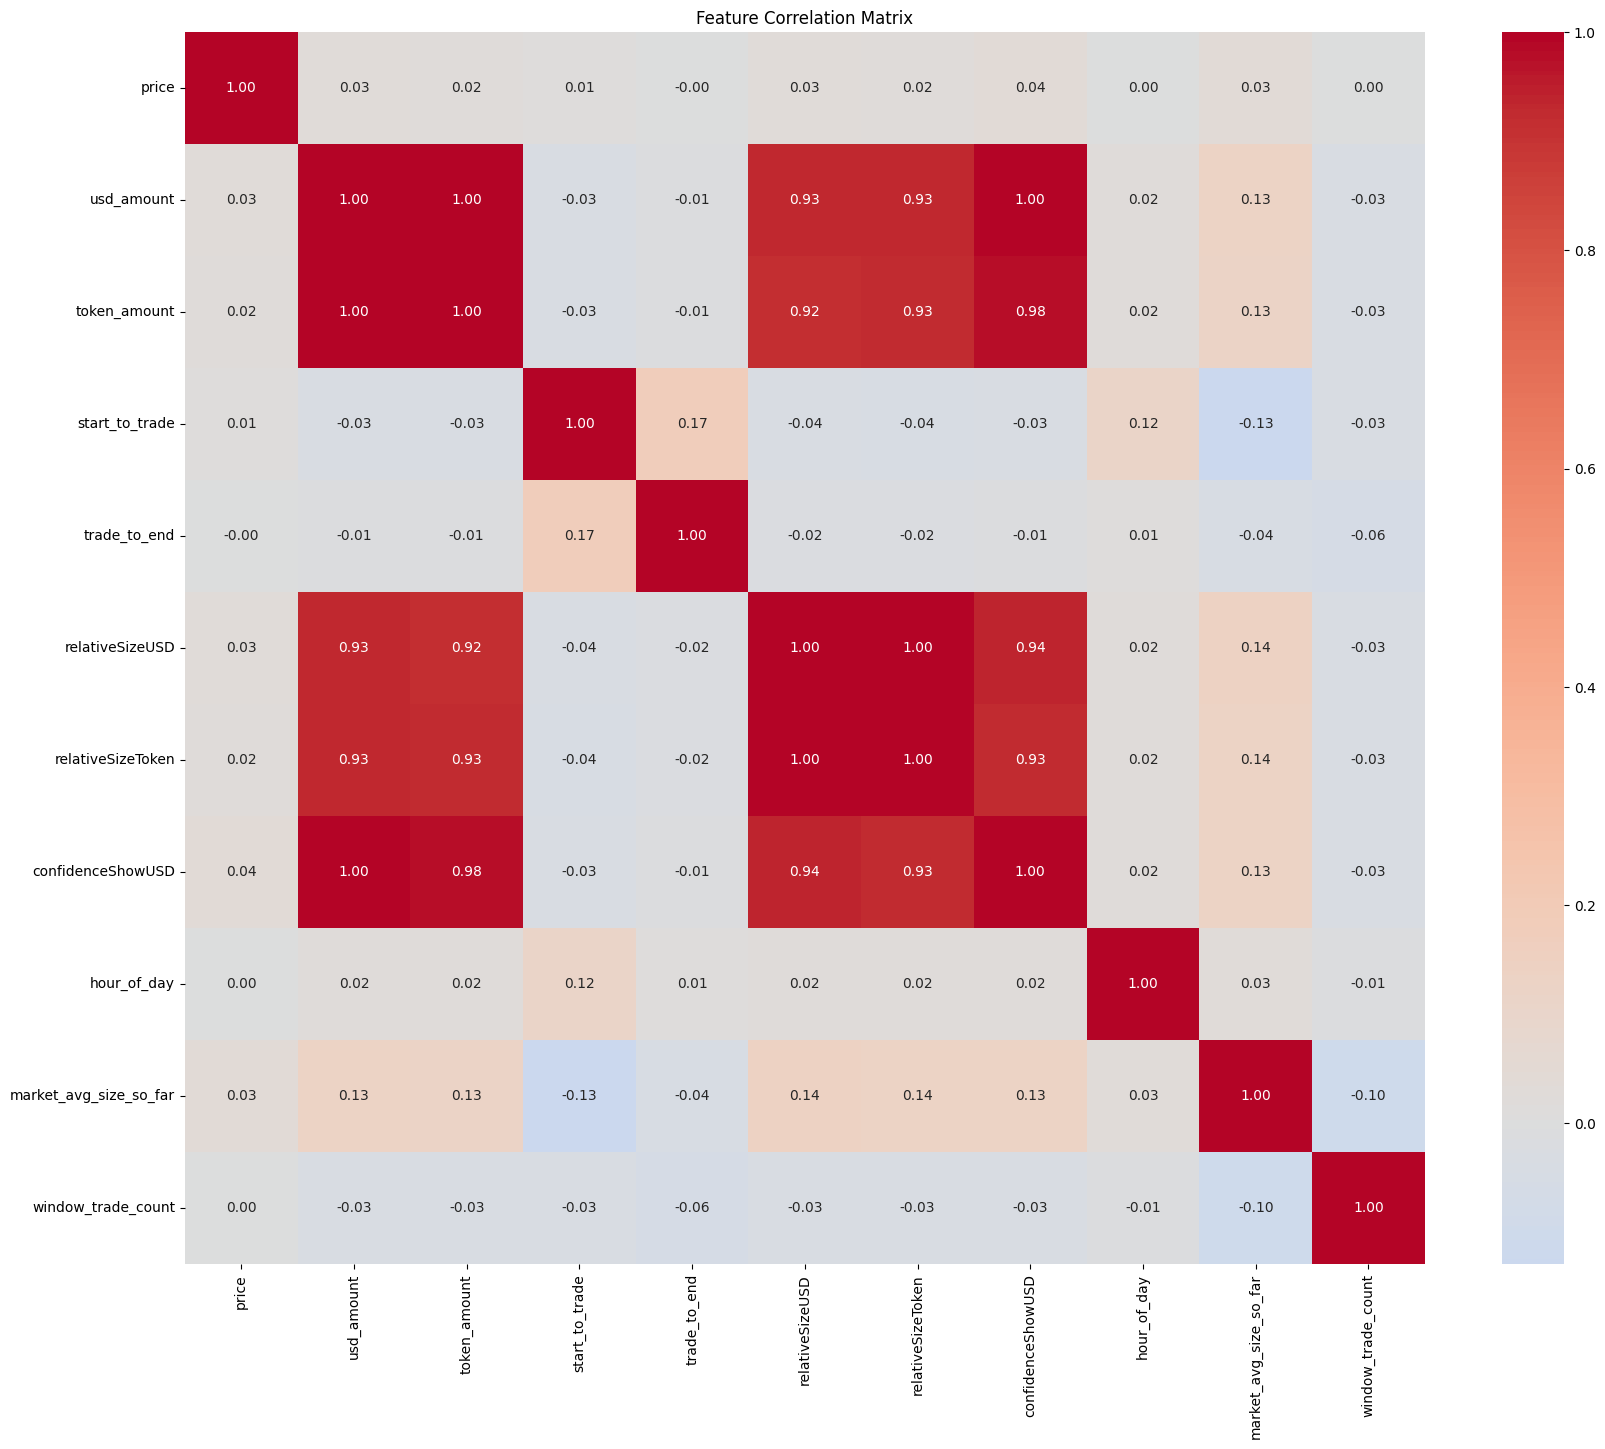

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

FEATURES = ['price','usd_amount','token_amount','start_to_trade','trade_to_end','relativeSizeUSD',
                  'relativeSizeToken','confidenceShowUSD','hour_of_day','market_avg_size_so_far',
                  'window_trade_count']
corr_matrix = df[FEATURES].corr()
print(corr_matrix)

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            annot=True,      # show values
            fmt='.2f',       # 2 decimal places
            cmap='coolwarm', # red to blue
            center=0)        # center colormap at 0

plt.title('Feature Correlation Matrix')

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
from Code.modelsMachine import XGBoostME

model = XGBoostME(df,FEATURES,20)

(4187, 45)
Individual folds: [0.693 0.683 0.676 0.671 0.656]
Mean accuracy:    0.6759
Std deviation:    0.0124
Train accuracy: 0.973
Test accuracy:  0.662
price                     0.135329
window_trade_count        0.106445
start_to_trade            0.097147
trade_to_end              0.096698
confidenceShowUSD         0.085893
market_avg_size_so_far    0.084872
relativeSizeToken         0.082181
hour_of_day               0.081921
token_amount              0.080315
relativeSizeUSD           0.077127
usd_amount                0.072073
dtype: float32


In [ ]:
from Code.modelsMachine import BaseLineME

BaseLineME(df,baseline = 0.45)

Baseline accuracy: 0.545
              precision    recall  f1-score   support

           0       0.58      0.32      0.41     77448
           1       0.53      0.77      0.63     77383

    accuracy                           0.54    154831
   macro avg       0.56      0.54      0.52    154831
weighted avg       0.56      0.54      0.52    154831

